In [1]:
import tensorflow as tf
import numpy as np
import sys
import torch

sys.path.insert(0, '/lustre/lrspec/users/4301/hxe-for-tda/hxetda')
import hxetda
import networkx as nx
import matplotlib.pyplot as plt

2026-08-10 13:59:26.913204: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-10 13:59:26.971755: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-10 13:59:29.265969: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Define a simple hierarchy
# 3 classes: Root (0), A (1), B (2)
mask_list = [
    np.array([1, 1, 0]),  # Level 1: Root + A
    np.array([1, 0, 1]),  # Level 2: Root +  B
]
pathlengths = np.array([1, 2, 2])  # Root:1, A:2, B:2

# Create dummy batch
batch_size = 4
num_classes = 3

# Predictions (logits)
y_pred = tf.constant([
    [2.0, 1.0, 0.5],
    [1.0, 2.0, 0.5],
    [0.5, 1.0, 2.0],
    [1.5, 0.5, 1.0]
    ], dtype=tf.float32)

# True labels (multi-hot)
y_true = tf.constant([
    [1, 1, 0],  # Class A
    [1, 0, 1],  # Class B
    [1, 1, 0],  # Class A
    [1, 0, 1],  # Class B
    [1, 0, 1],  # Class B
    ], dtype=tf.float32)

# labels
labels = ["A", "B", "A", "B", "B"]

2026-08-10 13:59:33.200800: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


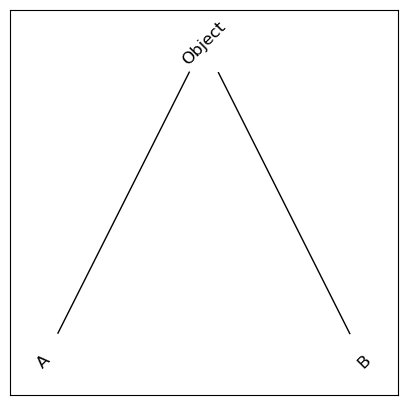

In [3]:
# create the labels

G=nx.DiGraph()
G.add_edge('Object', 'A')
G.add_edge('Object', 'B')
fig = plt.figure(1, figsize=(5, 5))

pos = hxetda.hierarchy_pos(G, 'Object')
nx.draw_networkx(G, pos=pos, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

In [113]:
leaves = np.asarray(['A', 'B'], dtype=str)
vertices = np.asarray(["Object", "A", "B"], dtype='<U17')
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'Object')

In [114]:
# mask_list shows the number of options in various parent groups
mask_list

[tensor([0, 1, 1])]

In [6]:
class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
class_weight_dict # these are the weights based on the class fraction 
# in the paper this is W(c)
weights = [class_weight_dict[x] for x in labels]
class_weights = [1, 1.25, 0.83333333]

In [7]:
list(class_weight_dict.values())

[array([1.25]), array([0.83333333])]

In [12]:
# from hxetda.py 

def masked_softmax(vec, mask, dim=1, epsilon=1e-10):
	masked_vec = vec * mask.float()
	exps = torch.exp(masked_vec)
	masked_exps = exps * mask.float()
	masked_sums = masked_exps.sum(dim, keepdim=True) + epsilon
	final_vec = masked_exps/masked_sums + ((1-mask) * vec)
	return final_vec

def custom_hier_loss(output, target, mask_list, pathlengths):
	final_sum = 0
	alpha = 0.5
	output[:, 0] = 1.0
    

	for i,mask in enumerate(mask_list):
		output = masked_softmax(output, mask)
	output = output.log()
	output = output * np.exp(-alpha * (pathlengths - 1))
	final_sum = (target_weights * (output*target).sum(dim=1)).mean()
	#final_sum = ((output*target).sum(dim=1)).mean()

	return -final_sum


In [30]:
y_pred = torch.tensor([
    [2.0, 1.0, 0.5],
    [1.0, 2.0, 0.5],
    [0.5, 1.0, 2.0],
    [1.5, 0.5, 1.0] ]).to(torch.float)

y_true = torch.tensor([
    [1, 1, 0],  # Class A
    [1, 0, 1],  # Class B
    [1, 1, 0],  # Class A
    [1, 0, 1],  # Class B 
    ]).to(torch.float)


weights = torch.tensor(weights, dtype=torch.float32)

hxetda.custom_hier_loss(y_pred, y_true, weights, mask_list, pathlengths)

/tmp/ipykernel_25983/342062525.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights = torch.tensor(weights, dtype=torch.float32)


tensor(0.6009)

In [17]:
# example custom loss
# https://towardsdatascience.com/creating-custom-loss-functions-in-tensorflow-understanding-the-theory-and-practicalities-383a19e387d6/

class WeightedCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, weight, epsilon=1e-7, name="weighted_cross_entropy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.weight = weight
        self.epsilon = epsilon

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, self.epsilon, 1 - self.epsilon)
        loss = -(self.weight * y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.math.reduce_mean(loss)

    def get_config(self):
        config = {
            'weight': self.weight,
            'epsilon': self.epsilon
        }
        base_config = super().get_config()
        return {**base_config, **config}

In [26]:
class WeightedHierchicalLoss(tf.keras.losses.Loss):
    def __init__(self, mask_list, pathlengths, class_weights, alpha = 0.5, epsilon=1e-10, 
                 name="weighted_hierchical_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mask_list = mask_list
        self.pathlengths = pathlengths
        self.alpha = alpha
        self.epsilon = epsilon
        self.class_weights = class_weights
    
    def masked_softmax(self, vec, mask):
        """ This produces the conditional probability of each branch from a parent
        denotated as p(c_(h)|c_(h+1)) in the paper"""
        masked_vec = vec * mask
        exps = tf.exp(masked_vec)
        masked_exps = exps * mask
        masked_sums = tf.reduce_sum(masked_exps, axis=1, keepdims=True) + self.epsilon
        final_vec = masked_exps/masked_sums + ((1-mask) * vec)
        return final_vec
    
    def call(self, y_true, y_pred):
        final_sum = 0
        # Convert tensors to float32
        y_pred = tf.cast(y_pred, tf.float32)
        # Set first column to 1.0 (can't do in-place assignment)
        output = tf.concat([tf.ones_like(y_pred[:, :1]), y_pred[:, 1:]], axis=1)
    
        for i,mask in enumerate(self.mask_list):
            output = self.masked_softmax(output, mask)
            
        output = tf.math.log(output)  # this gives us log[p(c_(h)|c_(h+1))]
    
        # this is log[p(c_(h)|c_(h+1))] * λ(c) 
        # λ(c) weights the different levels of the tree
        output = output * np.exp(-self.alpha * (self.pathlengths - 1)) 
    
        # this gives us W(c_h) * {log[p(c_h|c_(h+1))] * λ(c)}
        # W(c_h) weights each class by its class fraction 
        output = output * self.class_weights 

        # finally ({W(c_h) * log[p(c_h|c_(h+1))] * λ(c)} * y_true)
        output = tf.reduce_sum((output * y_true), axis=1)
    
        # finally we get the negative of all of this as the loss
        # I dont know why its the mean and not just the sum but it fundementally doesnt matter
        return -tf.reduce_mean(output)
        
    
    def get_config(self):
        config = {
            'alpha': self.alpha,
            'epsilon': self.epsilon,
            'mask_list': self.mask_list,
            'class_weights': self.sample_weights,
        }
        base_config = super().get_config()
        return {**base_config, **config}

In [67]:
y_true

tensor([[1., 1., 0.],
        [1., 0., 1.],
        [1., 1., 0.],
        [1., 0., 1.]])

In [69]:
np.array(y_true).shape[1]

3

In [75]:
np.ones((4))*4

array([4., 4., 4., 4.])

Metric used to weight class in the HXETDA
$$
W(c^{(h)}) =  N_{all}/(N_{Labels} \times N_c)
$$
"$N_{All}$ is the total number of events in the dataset, $N_{Labels}$ is the number of unique classes, and $N_c$ is the number of events of class c"

Going to weigh the classes using this metric but they did it by weighting each sample so the result will be different. $N_{All}$ will represent all classifications so if one sample has 4 total classes it will be contribute for the $N_{All}$ value.

In [89]:
def class_weights(y_true):
    """this is going to create the weight vector for classes using the papers metric"""
    N_All = y_true.sum()
    N_c = y_true.sum(axis = 0)
    N_Labels = y_true.shape[1]
    W = np.ones(int(N_Labels)) * N_All / N_c
    W = W / N_Labels
    return W

In [119]:
y_true = [[1., 1., 0.],
        [1., 0., 1.],
        [1., 1., 0.],
        [1., 0., 1.],
         [1., 0., 1.]]

In [120]:
class_weights(np.array(y_true))

array([0.66666667, 1.66666667, 1.11111111])

In [121]:
class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
class_weight_dict

{np.str_('A'): array([1.25]), np.str_('B'): array([0.83333333])}

In [50]:
# Simple test of just the loss function
def quick_loss_test():
    print("QUICK LOSS FUNCTION TEST")
    print("-" * 40)
    
    # Define a simple hierarchy
    # 3 classes: Root (0), A (1), B (2)
    mask_list = [
        np.array([1, 1, 0]),  # Level 1: Root + A
        np.array([1, 0, 1]),  # Level 2: Root +  B
    ]
    pathlengths = np.array([1, 2, 2])  # Root:1, A:2, B:2

    # Class weights
    # class_weight = np.array([1.0, 0.5, 1.0, 0.5])
    class_weights = np.array([1.0, 1.25, 0.83333333])
    class_weights = np.array([1., 1., 1.])

    # Sample weights
    weights_torch = torch.tensor([[1.], # Class A
                            [1.], # Class B
                            [1.], # Class A
                            [1.],
                            [1.]] # Class B
                           , dtype=torch.float32)
    # weights_torch = torch.tensor([[1.25], # Class A
    #                         [0.83333333], # Class B
    #                         [1.25], # Class A
    #                         [0.83333333]] # Class B
    #                        , dtype=torch.float32)

    
    # Create loss function
    loss_fn = WeightedHierchicalLoss(mask_list, pathlengths, class_weights, alpha=0.5)
    
    # Create dummy batch
    batch_size = 4
    num_classes = 3
    
    # Predictions (logits)
    y_pred = np.array([
        [2.0, 1.0, 0.5],
        [1.0, 2.0, 0.5],
        [0.5, 1.0, 2.0],
        [1.5, 0.5, 1.0],
        [1.5, 0.5, 1.0],
    ])
    
    # True labels (one-hot)
    y_true = np.array([
        [1, 1, 0],  # Class A
        [1, 0, 1],  # Class B
        [1, 1, 0],  # Class A
        [1, 0, 1],  # Class B
        [1, 0, 1],  # Class B
    ])

    # hxe tda verion
    y_pred_torch = torch.tensor(y_pred).to(torch.float)
    y_true_torch = torch.tensor(y_true).to(torch.float)
    mask_list_torch = torch.tensor(mask_list).to(torch.float)
    hxetda_loss = hxetda.custom_hier_loss(y_pred_torch, y_true_torch, weights_torch, mask_list_torch, pathlengths)
    
    # Compute loss
    loss_value = loss_fn(y_true, y_pred)
    
    print(f"Batch size: {batch_size}")
    print(f"Number of classes: {num_classes}")
    print(f"Predictions shape: {y_pred.shape}")
    print(f"True labels shape: {y_true.shape}")
    print()
    print(f"My Loss value: {loss_value.numpy():.5f}")
    print(f"HXETDA Loss value: {hxetda_loss.numpy():.5f}")
    print()

    if loss_value == hxetda_loss:
        print("THEY MATCH")
    else:
        print("they dont match :(")
    
    # return loss_value.numpy()

# Run quick test
quick_loss_test()

QUICK LOSS FUNCTION TEST
----------------------------------------
Batch size: 4
Number of classes: 3
Predictions shape: (5, 3)
True labels shape: (5, 3)

My Loss value: 1.36754
HXETDA Loss value: 1.36754

they dont match :(


In [98]:
np.ones((4,1))

array([[1.],
       [1.],
       [1.],
       [1.]])

In [125]:
# Simple test of just the loss function


def generate_test_data(y_len, num_classes=3):
    """
    Generate random test data for hierarchical loss testing
    
    Args:
        y_len: Number of samples (rows)
        num_classes: Number of classes (columns)
    
    Returns:
        y_pred: Random prediction logits
        y_true: One-hot encoded labels
    """
    # Generate random predictions (logits) between 0 and 3
    y_pred = np.random.uniform(0, 3, size=(y_len, num_classes))
    
    # Generate random one-hot labels
    # First column is always 1 (root node)
    # Randomly select one of the child classes for each sample
    child_indices = np.random.randint(1, num_classes, size=y_len)
    y_true = np.zeros((y_len, num_classes))
    y_true[:, 0] = 1  # Always include root
    y_true[np.arange(y_len), child_indices] = 1
    
    return y_pred, y_true

    
def quick_loss_test_len(y_len= 4):
    print("QUICK LOSS FUNCTION TEST")
    print("-" * 40)
    
    # Define a simple hierarchy
    # 3 classes: Root (0), A (1), B (2)
    mask_list = [
        np.array([1, 1, 0]),  # Level 1: Root + A
        np.array([1, 0, 1]),  # Level 2: Root +  B
    ]
    pathlengths = np.array([1, 2, 2])  # Root:1, A:2, B:2

    # Class weights
    class_weights = np.array([1., 1., 1.])

    # Sample weights
    weights_torch = torch.tensor(np.ones((y_len,1)), dtype=torch.float32)

    
    # Create loss function
    loss_fn = WeightedHierchicalLoss(mask_list, pathlengths, class_weights, alpha=0.5)
    
    # Create dummy batch
    num_classes = 3
    
    y_pred, y_true = generate_test_data(y_len)

    # hxe tda verion
    y_pred_torch = torch.tensor(y_pred).to(torch.float)
    y_true_torch = torch.tensor(y_true).to(torch.float)
    mask_list_torch = torch.tensor(mask_list).to(torch.float)
    hxetda_loss = hxetda.custom_hier_loss(y_pred_torch, y_true_torch, weights_torch, mask_list_torch, pathlengths)
    
    # Compute loss
    loss_value = loss_fn(y_true, y_pred)
    
    print(f"Number of classes: {num_classes}")
    print(f"Predictions shape: {y_pred.shape}")
    print(f"True labels shape: {y_true.shape}")
    print()
    print(f"My Loss value: {loss_value.numpy():.5f}")
    print(f"HXETDA Loss value: {hxetda_loss.numpy():.5f}")
    print()

    if np.isclose(loss_value, hxetda_loss):
        print("THEY MATCH")
    else:
        print("they dont match :(")
    
    # return loss_value.numpy()

In [128]:
len_test_list = [3, 5, 10, 15, 30, 50, 100, 1000, 2000]
for y_len in len_test_list:
    quick_loss_test_len(y_len) 

QUICK LOSS FUNCTION TEST
----------------------------------------
Number of classes: 3
Predictions shape: (3, 3)
True labels shape: (3, 3)

My Loss value: 1.40834
HXETDA Loss value: 1.40834

THEY MATCH
QUICK LOSS FUNCTION TEST
----------------------------------------
Number of classes: 3
Predictions shape: (5, 3)
True labels shape: (5, 3)

My Loss value: 2.00493
HXETDA Loss value: 2.00493

THEY MATCH
QUICK LOSS FUNCTION TEST
----------------------------------------
Number of classes: 3
Predictions shape: (10, 3)
True labels shape: (10, 3)

My Loss value: 1.19126
HXETDA Loss value: 1.19126

THEY MATCH
QUICK LOSS FUNCTION TEST
----------------------------------------
Number of classes: 3
Predictions shape: (15, 3)
True labels shape: (15, 3)

My Loss value: 1.37485
HXETDA Loss value: 1.37485

THEY MATCH
QUICK LOSS FUNCTION TEST
----------------------------------------
Number of classes: 3
Predictions shape: (30, 3)
True labels shape: (30, 3)

My Loss value: 1.59342
HXETDA Loss value: 1.59